<a href="https://colab.research.google.com/github/Amanbaghel-max/MyProject/blob/main/SY_A_08_P8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Aman baghel  | Class: SY-AI&DS-A | Roll No.: A-08 | Practical : 09

AIM:
**AIM: **

To implement and analyse different methods of studying correlation and regression, including Karl Pearson's coefficient and simple linear regression using Python.

Theory

What is correlation? How does it differ from regression? Correlation is a statistical measure that evaluates both the strength and direction of the linear association between two variables. It indicates whether the variables tend to increase together, move in opposite directions, or have no discernible relationship. Regression, by contrast, is an analytical technique used to express the relationship between variables mathematically, with the primary goal of predicting the value of one variable (the dependent variable) from another (the independent variable). Key distinctions between the two: • Correlation quantifies association but does not support prediction; regression is prediction focused. • Correlation is a symmetric measure — the result is the same regardless of which variable is treated as X or Y. Regression is directional — X is the predictor and Y is the response. • Correlation produces a dimensionless coefficient ranging from -1 to +1; regression produces an equation with slope and intercept.

Explain simple linear regression with an appropriate example. Simple linear regression is a statistical approach for modeling the relationship between a single explanatory variable and a continuous outcome variable through a linear equation of the form: y = mx + c Where y is the predicted (dependent) variable, x is the input (independent) variable, m represents the slope (rate of change), and c is the y-intercept (value of y when x = 0). Example: If we want to predict a student's exam score (y) based on the number of hours studied (x), simple linear regression fits a straight line through the data points that best minimizes prediction error.

What is Karl Pearson's coefficient of correlation? Karl Pearson's coefficient of correlation, commonly denoted as 'r', is one of the most widely used measures of linear association between two continuous variables. It is computed as the ratio of the covariance of the two variables to the product of their individual standard deviations. The value of r always lies between -1 and +1, where: r = +1 indicates a perfect positive linear relationship, r = -1 indicates a perfect negative linear relationship, and r = 0 implies no linear correlation exists between the variables.

What are the assumptions of linear regression? Linear regression relies on several key assumptions for its results to be valid and reliable: • Linearity: The relationship between the independent and dependent variable must be linear in nature. • Independence: Each observation in the dataset should be collected independently of the others. • Homoscedasticity: The variance of the residuals (prediction errors) should remain roughly constant across all levels of the independent variable. • Normality of residuals: The errors generated by the model should approximately follow a normal distribution. • No multicollinearity: In multiple regression scenarios, the predictor variables should not be highly correlated with each other.

What is the significance of R-squared in regression analysis? R-squared, also referred to as the coefficient of determination, is a metric that reflects how well the regression model explains the variability present in the dependent variable. Its value ranges from 0 to 1. An R-squared value of 1.0 means the model accounts for all variation in the response variable, while a value of 0 indicates the model has no explanatory power beyond the mean. In general, a higher R squared is preferred, but it should always be interpreted alongside domain knowledge, as a high R squared can sometimes result from overfitting.



In [ ]:
import requests

# URL of the raw CSV file on GitHub
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

# Path where the file will be saved in Colab
file_path = "/content/titanic.csv"

# Download the file
response = requests.get(url)

# Check if the download was successful
if response.status_code == 200:
    with open(file_path, 'wb') as f:
        f.write(response.content)
    print(f"'{file_path}' downloaded successfully.")
else:
    print(f"Failed to download the file. Status code: {response.status_code}")


'/content/titanic.csv' downloaded successfully.


    Age     Fare  Survived
0  22.0   7.2500         0
1  38.0  71.2833         1
2  26.0   7.9250         1
3  35.0  53.1000         1
4  35.0   8.0500         0
Correlation Matrix:

               Age      Fare  Survived
Age       1.000000  0.096067 -0.077221
Fare      0.096067  1.000000  0.268189
Survived -0.077221  0.268189  1.000000
Slope (m): 0.34996368174402326
Intercept (c): 24.300901449288645


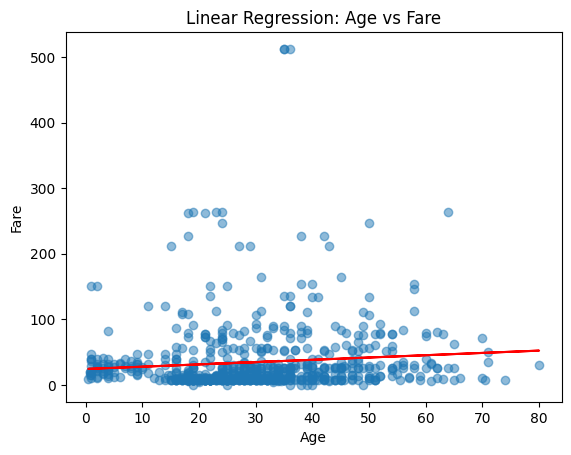

          Survived       Age      Fare
Survived  1.000000 -0.077221  0.268189
Age      -0.077221  1.000000  0.096067
Fare      0.268189  0.096067  1.000000


In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/titanic.csv")

# Retain only relevant numeric columns
df = df[['Age', 'Fare', 'Survived']].dropna()

# Preview the data
print(df.head())

# Generate full correlation matrix
corr_matrix = df.corr()
print("Correlation Matrix:\n")
print(corr_matrix)

# Define feature and target for regression
feat = df[['Age']]
target = df['Fare']

# Build and fit the regression model
reg_model = LinearRegression()
reg_model.fit(feat, target)

# Compute predicted values
target_pred = reg_model.predict(feat)

print("Slope (m):", reg_model.coef_[0])
print("Intercept (c):", reg_model.intercept_)

# Visualize the regression result
plt.scatter(feat, target, alpha=0.5)
plt.plot(feat, target_pred, color='red')
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Linear Regression: Age vs Fare")
plt.show()
# Examine correlation with survival outcome
print(df[['Survived', 'Age', 'Fare']].corr())

**Conclusion **

This practical involved applying correlation analysis and linear regression to the Titanic dataset using Python's pandas and scikit-learn libraries. Three numeric variables — Age, Fare, and Survived — were extracted and examined for linear associations using Pearson's correlation matrix. The correlation analysis revealed that none of the variable pairs exhibited a particularly strong linear relationship. The correlation between Age and Survival was mildly negative (-0.077), while Fare showed a slightly more positive correlation with Survival (0.268), suggesting that passengers who paid higher fares had a marginally better survival rate. A simple linear regression model was built to estimate Fare values from Age. The resulting slope was approximately 0.35 and the intercept was around 24.3, meaning that for each additional year of age, the predicted fare increased marginally. However, the visual scatter in the regression plot makes it clear that Age alone is a weak predictor of Fare. This experiment highlights that real-world datasets rarely exhibit clean linear relationships, and that accurate predictions often require incorporating multiple features and more sophisticated modeling techniques.